# 3. Supervised Learning - Stage 3

**Goal:** Establish a simple, interpretable baseline classifier.

Logistic Regression is trained first because:
- It is the simplest meaningful classifier for multi-class problems
- Its coefficients are interpretable (we can reason about feature influence)
- It sets a performance floor that all subsequent models must beat to justify their complexity
- It assumes a linear decision boundary, which is unlikely to hold for collision data - making it a useful contrast to tree-based models

In [24]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

def find_project_root(marker='config.yml'):
    current = Path().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Could not find {marker} in any parent directory')

ROOT_DIR = find_project_root()
NOTEBOOKS_DIR = ROOT_DIR / 'notebooks'

with open(ROOT_DIR / 'config.yml') as f:
    cfg = yaml.safe_load(f)

with open(NOTEBOOKS_DIR / 'notebook-config.yml') as f:
    nb_cfg = yaml.safe_load(f)

NB_CONFIG = {
    'figsize_wide':    nb_cfg['plotting']['figsize_wide'],
    'figsize_square':  nb_cfg['plotting']['figsize_square'],
    'palette':         nb_cfg['plotting']['palette'],
    'severity_labels': {int(k): v for k, v in nb_cfg['labels']['severity'].items()},
}

sns.set_theme(style='whitegrid', palette=NB_CONFIG['palette'])
print(f'Project root: {ROOT_DIR}')
print('Configs loaded.')

Project root: C:\Users\abdul\Documents\SHU\AI 1\Sheffield-Road-Collision-Detection-Coursework
Configs loaded.


---
# 2. Load Stage 2 Outputs

In [25]:
with open(NOTEBOOKS_DIR / 'stage_outputs' / 'stage2.pkl', 'rb') as f:
    stage2 = pickle.load(f)

X_train = stage2['X_train_resampled']
y_train = stage2['y_train_resampled']
X_test = stage2['X_test']
y_test = stage2['y_test']

class_names = [NB_CONFIG['severity_labels'][c] for c in sorted(y_test.unique())]

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'Classes:      {class_names}')

Training set: (14646, 28)
Test set:     (1465, 28)
Classes:      ['Fatal', 'Serious', 'Slight']


---
# 3. Feature Scaling

Logistic regression is senstive to feature scale - unlike tree-based models, it uses gradient-based optimization where large magnitude features can dominate. `StandardScaler` is applied here (zero mean, unit variance).

> The scaler is only fit on the training data to prevent data leakage into the test set

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling applied. Train/test shapes unchanged:')
print(f'  X_train_scaled: {X_train_scaled.shape}')
print(f'  X_test_scaled:  {X_test_scaled.shape}')

Scaling applied. Train/test shapes unchanged:
  X_train_scaled: (14646, 28)
  X_test_scaled:  (1465, 28)


---
# 4. Train Logistic Regression

In [27]:
lr_params = cfg['supervised']['models']['logistic_regression']

lr_model = LogisticRegression(
    max_iter=lr_params['max_iter'],
    class_weight=lr_params['class_weight'],
    solver='lbfgs',
    random_state=cfg['supervised']['random_state'],
)

lr_model.fit(X_train_scaled, y_train)
print('Model trained.')
print(f'Solver:       {lr_model.solver}')
print(f'Iterations:   {lr_model.n_iter_[0]} / {lr_model.max_iter}')
print(f'Classes:      {lr_model.classes_}')

Model trained.
Solver:       lbfgs
Iterations:   18 / 1000
Classes:      [1 2 3]


---
# 5. Evaluate Test Set

In [28]:
y_pred = lr_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_per_class = f1_score(y_test, y_pred, average=None)

print(f'Accuracy:          {accuracy:.4f}')
print(f'Weighted F1:       {f1_weighted:.4f}')
print(f'Macro F1:          {f1_macro:.4f}')
print()
print('Per-class F1:')
for cls, f1 in zip(sorted(y_test.unique()), f1_per_class):
    print(f'  {NB_CONFIG["severity_labels"][cls]:8s}: {f1:.4f}')

Accuracy:          0.5147
Weighted F1:       0.5949
Macro F1:          0.3083

Per-class F1:
  Fatal   : 0.0433
  Serious : 0.2060
  Slight  : 0.6756


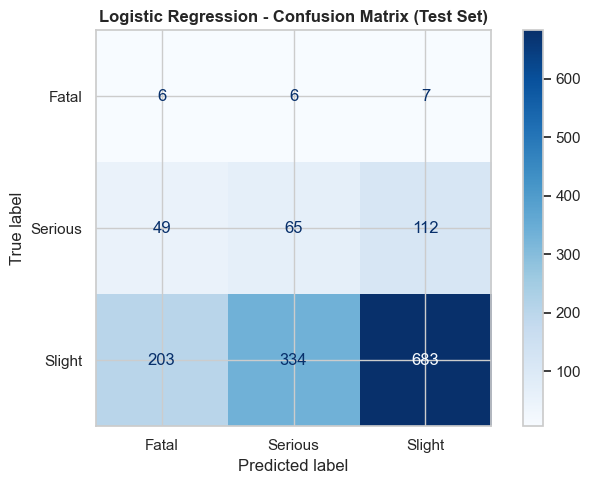


Fatal correctly identified:   6 / 19 (31.6%)
Serious correctly identified: 65 / 226 (28.8%)
Slight correctly identified:  683 / 1220 (56.0%)


In [29]:
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title('Logistic Regression - Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nFatal correctly identified:   {cm[0,0]} / {cm[0].sum()} ({cm[0,0]/cm[0].sum():.1%})')
print(f'Serious correctly identified: {cm[1,1]} / {cm[1].sum()} ({cm[1,1]/cm[1].sum():.1%})')
print(f'Slight correctly identified:  {cm[2,2]} / {cm[2].sum()} ({cm[2,2]/cm[2].sum():.1%})')

---
# 6. Coefficient Analysis
One of the key advantages of Logistic Regression is interpretability. The coefficients
show the influence of each feature on each class prediction.

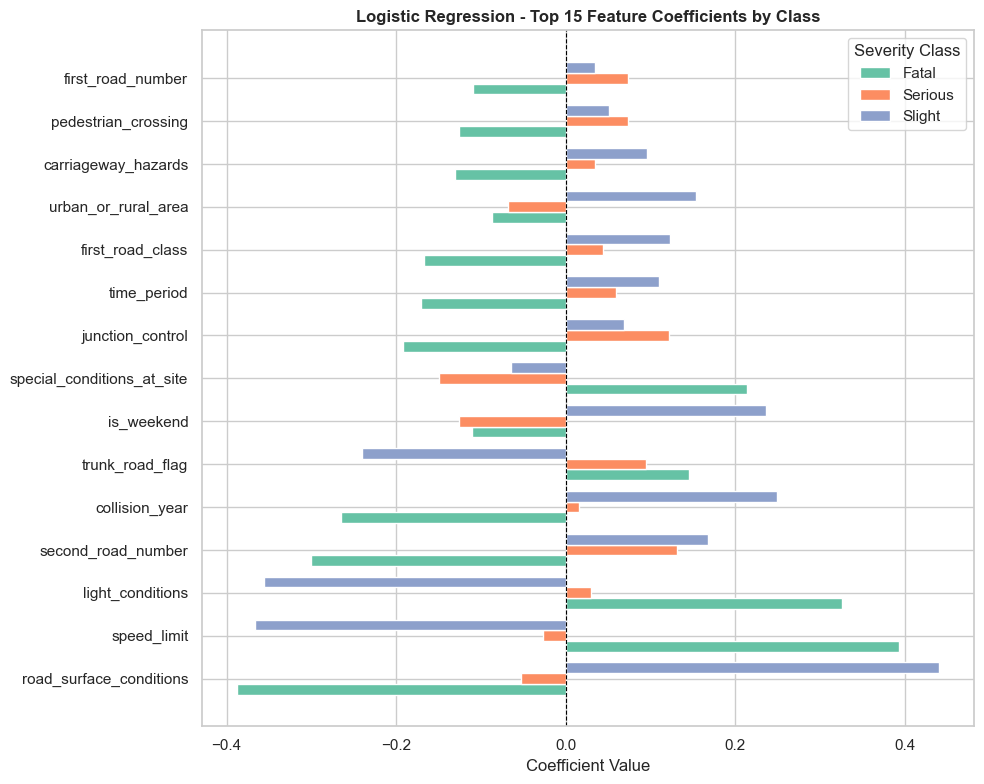

In [30]:
feature_names = X_train.columns.tolist()
coef_df = pd.DataFrame(
    lr_model.coef_,
    index=class_names,
    columns=feature_names
).T

coef_df['mean_abs'] = coef_df.abs().mean(axis=1)
top_features = coef_df.nlargest(15, 'mean_abs').drop(columns='mean_abs')

fig, ax = plt.subplots(figsize=tuple(NB_CONFIG['figsize_square']))
colors = sns.color_palette(NB_CONFIG['palette'], len(class_names))

x = np.arange(len(top_features))
width = 0.25

for i, (cls_name, color) in enumerate(zip(class_names, colors, strict=False)):
    ax.barh(
        x + i * width,
        top_features[cls_name],
        height=width,
        label=cls_name,
        color=color
    )

ax.set_yticks(x + width)
ax.set_yticklabels(top_features.index)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression - Top 15 Feature Coefficients by Class',
             fontsize=12, fontweight='bold')
ax.legend(title='Severity Class')
plt.tight_layout()
plt.show()

---
## 7. Limitations of This Baseline

- **Linear decision boundary** - collision severity is unlikely to be linearly separable in feature space. The model will struggle with the complex interactions between road type, speed limit, time of day, and weather that tree-based models can capture naturally.
- **Fatal class recall** - even with SMOTE and `class_weight='balanced'`, Logistic Regression may still misclassify Fatal collisions due to their sparse and complex feature patterns.
- **No feature interactions** - relationships like `high speed limit AND wet road AND night` are not captured unless explicitly engineered.

These limitations motivate the use of Random Forest and XGBoost in subsequent stages.

**Next: Stage 4 - Random Forest.**

In [31]:
output_path = NOTEBOOKS_DIR / 'stage_outputs' / 'stage3.pkl'

with open(output_path, 'wb') as f:
    pickle.dump({
        'model':        lr_model,
        'scaler':       scaler,
        'y_pred':       y_pred,
        'y_test':       y_test,
        'accuracy':     accuracy,
        'f1_weighted':  f1_weighted,
        'f1_macro':     f1_macro,
        'f1_per_class': f1_per_class,
        'model_name':   'Logistic Regression',
    }, f)

print(f'Stage 3 outputs saved to: {output_path}')

Stage 3 outputs saved to: C:\Users\abdul\Documents\SHU\AI 1\Sheffield-Road-Collision-Detection-Coursework\notebooks\stage_outputs\stage3.pkl
